In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [14]:
url = "https://raw.githubusercontent.com/Gilberto625/F1MExico/refs/heads/main/Mexico2024.csv"

data = pd.read_csv(url)

print("Shape:", data.shape)
data.head(5)

Shape: (1215, 9)


,Driver,LapNumber,Position,LapTime,Sector1Time,Sector2Time,Sector3Time,MaxSpeed,Compound
0,SAI,1.0,4.0,107.224,NaN,41.495,33.841,310.0,MEDIUM
1,SAI,2.0,2.0,137.937,61.514,46.266,30.157,194.0,MEDIUM
2,SAI,3.0,2.0,133.771,56.743,47.358,29.670,142.0,MEDIUM
3,SAI,4.0,2.0,130.043,52.782,46.662,30.599,122.0,MEDIUM
4,SAI,5.0,2.0,129.925,53.462,46.644,29.819,158.0,MEDIUM


In [15]:
data.isnull().sum()

Driver           0
LapNumber        0
Position         0
LapTime          2
Sector1Time     22
Sector2Time      4
Sector3Time      2
MaxSpeed       225
Compound         0
dtype: int64

In [16]:
# Eliminar filas donde la variable objetivo no existe
data = data.dropna(subset=["LapTime"]).reset_index(drop=True)

# Rellenar nulos en columnas numéricas (excepto LapTime) con la mediana
numeric_cols = data.select_dtypes(include="number").columns.drop("LapTime")
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

In [17]:
data.isnull().sum()

Driver         0
LapNumber      0
Position       0
LapTime        0
Sector1Time    0
Sector2Time    0
Sector3Time    0
MaxSpeed       0
Compound       0
dtype: int64

In [18]:
categorical_cols = ["Driver", "Compound"]

ordinal_encoder = OrdinalEncoder()
data[categorical_cols] = ordinal_encoder.fit_transform(data[categorical_cols].astype(str))

print("Columnas categóricas codificadas:", categorical_cols)
data.head(5)

Columnas categóricas codificadas: ['Driver', 'Compound']


,Driver,LapNumber,Position,LapTime,Sector1Time,Sector2Time,Sector3Time,MaxSpeed,Compound
0,14.0,1.0,4.0,107.224,28.956,41.495,33.841,310.0,1.0
1,14.0,2.0,2.0,137.937,61.514,46.266,30.157,194.0,1.0
2,14.0,3.0,2.0,133.771,56.743,47.358,29.670,142.0,1.0
3,14.0,4.0,2.0,130.043,52.782,46.662,30.599,122.0,1.0
4,14.0,5.0,2.0,129.925,53.462,46.644,29.819,158.0,1.0


In [19]:
X = data.drop(columns=["LapTime"])
y = data["LapTime"]

print("Características usadas inicialmente:", list(X.columns))
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Características usadas inicialmente: ['Driver', 'LapNumber', 'Position', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'MaxSpeed', 'Compound']
Shape X: (1213, 8)
Shape y: (1213,)


In [20]:
modelo_selector = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

selector = SelectFromModel(
    estimator=modelo_selector,
    threshold="mean"
)

selector.fit(X, y)

importancias = pd.DataFrame({
    "Característica": X.columns,
    "Importancia": selector.estimator_.feature_importances_,
    "Seleccionada": selector.get_support()
}).sort_values(by="Importancia", ascending=False)

caracteristicas_seleccionadas = importancias.loc[
    importancias["Seleccionada"],
    "Característica"
].tolist()

# Si el selector deja muy pocas variables, se toman las 5 más importantes
if len(caracteristicas_seleccionadas) < 3:
    caracteristicas_seleccionadas = importancias.head(5)["Característica"].tolist()

print("Características seleccionadas:", caracteristicas_seleccionadas)

Características seleccionadas: ['Sector3Time', 'Sector1Time', 'LapNumber', 'Sector2Time', 'Position']


In [21]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
kf = KFold(n_splits=7, shuffle=True, random_state=42)

scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error'
}

scores = cross_validate(rf, X, y, cv=kf, scoring=scoring)

r2_scores = scores['test_r2']
mae_scores = np.abs(scores['test_mae'])

print(f"R² por fold  : {np.round(r2_scores, 4).tolist()}")
print(f"MAE por fold : {np.round(mae_scores, 2).tolist()}")
print(f"Promedio R²  : {np.mean(r2_scores):.4f}")
print(f"Promedio MAE : {np.mean(mae_scores):.2f}")

R² por fold  : [0.9858, 0.995, 0.9982, 0.9988, 0.9977, 0.997, 0.9986]
MAE por fold : [0.25, 0.28, 0.19, 0.18, 0.18, 0.22, 0.12]
Promedio R²  : 0.9959
Promedio MAE : 0.20


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)

y_pred = rf_final.predict(X_test)

r2_final = r2_score(y_test, y_pred)
mae_final = mean_absolute_error(y_test, y_pred)

print(f"R² final   : {r2_final:.4f}")
print(f"MAE final  : {mae_final:.2f}")

R² final   : 0.9773
MAE final  : 0.48


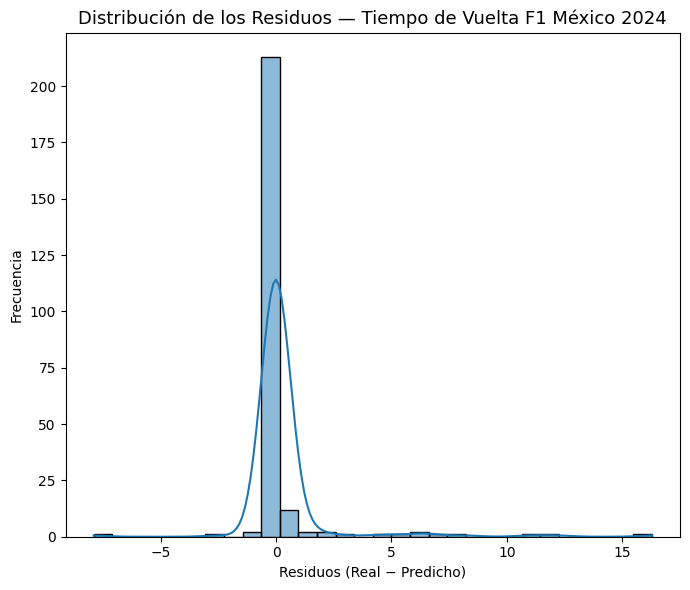

In [23]:
residuos = y_test - y_pred

plt.figure(figsize=(7, 6))
sns.histplot(residuos, kde=True, bins=30)
plt.title('Distribución de los Residuos — Tiempo de Vuelta F1 México 2024', fontsize=13)
plt.xlabel('Residuos (Real − Predicho)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

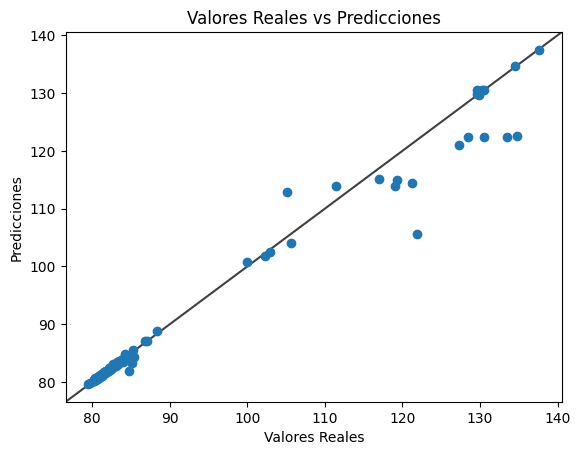

In [24]:
# Creando el diagrama de dispersión
plt.scatter(y_test, y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Valores Reales vs Predicciones')

# Añadiendo una línea de identidad, que representa una predicción perfecta
lims = [np.min([plt.xlim(), plt.ylim()]),  np.max([plt.xlim(), plt.ylim()])]
plt.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
plt.xlim(lims)
plt.ylim(lims)
plt.show()